# LABORATORIO 4 — Técnicas Estadísticas para el Análisis de Datos con Python

**Curso:** Analítica de Datos (202W1001 — Plan 2023)

**Escuela:** E.P. Ingeniería de Software — Facultad de Ingeniería de Sistemas e Informática — UNMSM

**Estudiante:** Luis Calle Huamantinco

**Código:** 22200255

**Semestre académico:** 2026-2 | Ciclo X | Unidad I

**Fecha:** 15/09/2026

**Docente:** Mg. Juan Gamarra Moreno

## Paso 0.1 - Cargar los archivos de datos

In [1]:
import os
print(os.listdir("."))

['Lab04_Guia_Tecnicas_Estadisticas_Analitica_de_Datos.md', 'pedidos_mercaandina_2026.csv', 'fig_paso_1_4.png', 'fig_paso_3_1.png', 'caso_mercaandina_semana04.py', 'Lab04_Guia_Tecnicas_Estadisticas_Analitica_de_Datos.pdf', 'LAB04_CalleHuamantincoLuis.ipynb', 'transacciones_api_billetera_2026.csv', 'experimento_checkout_2026.csv']


## Paso 0.3 - Importar librerías y verificar versiones

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import statsmodels
from statsmodels.stats.proportion import (proportions_ztest,
    proportion_confint, proportion_effectsize)
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.multitest import multipletests
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
SEMILLA = 2026
print("pandas", pd.__version__, "| scipy", scipy.__version__,
      "| statsmodels", statsmodels.__version__)

pandas 3.0.5 | scipy 1.18.1 | statsmodels 0.15.0


## Parte 1. Exploración y estadística descriptiva robusta

### Paso 1.1. Cargar y revisar el dataset

In [3]:
df = pd.read_csv("pedidos_mercaandina_2026.csv")
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.isna().sum())

(12000, 6)
region              str
canal               str
metodo_pago         str
ticket          float64
dias_entrega    float64
satisfaccion    float64
dtype: object
  region canal        metodo_pago   ticket  dias_entrega  satisfaccion
0   Lima   App            Tarjeta 108.8100        2.0000        5.0000
1  Norte   App            Tarjeta  67.1500        4.0000        5.0000
2  Norte   App            Tarjeta 100.3500        7.0000        3.0000
3   Lima   Web  Billetera digital  92.3600        3.0000        4.0000
4   Lima   Web            Tarjeta  18.8700        1.0000        5.0000
region            0
canal             0
metodo_pago       0
ticket            0
dias_entrega      0
satisfaccion    180
dtype: int64


**1.** La única variable con faltantes es satisfaccion, con 180 valores nulos sobre 12 000 filas, un 1.5% del total.

**2.** region, canal y metodo_pago son nominales (categorías sin orden). dias_entrega es de razón discreta: tiene cero absoluto pero solo toma valores enteros. ticket es de razón continua. satisfaccion es ordinal, porque el 1-5 tiene un orden pero no una distancia necesariamente uniforme entre categorías.

### Paso 1.2. Resumen robusto del ticket por canal

In [4]:
def resumen_robusto(x):
    x = x.dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    return pd.Series({
        "n": x.count(), "media": x.mean(), "mediana": x.median(),
        "media_rec_10": stats.trim_mean(x, 0.10),
        "desv_est": x.std(), "IQR": q3 - q1,
        "MAD_esc": stats.median_abs_deviation(x, scale="normal"),
        "CV_%": x.std() / x.mean() * 100,
        "asimetria": stats.skew(x), "P90": x.quantile(0.90),
        "P95": x.quantile(0.95)})

In [5]:
tabla_canal = df.groupby("canal")["ticket"].apply(resumen_robusto).unstack()
print(tabla_canal.T.round(2))   # traspuesta: filas = medidas

canal              App       Web
n            5324.0000 6676.0000
media         163.0800  157.7300
mediana       135.7000  132.1200
media_rec_10  146.2800  141.2400
desv_est      124.4500  127.7100
IQR           104.1800  103.5800
MAD_esc        71.4200   71.2100
CV_%           76.3100   80.9700
asimetria       7.1700    8.8000
P90           279.9600  271.4500
P95           345.5600  330.9000


**1.** La media es mayor que la mediana en ambos canales porque el ticket tiene asimetría positiva muy fuerte (7.17 en App y 8.80 en Web): hay compras corporativas atípicas mucho más altas que el resto que jalan la media hacia arriba, mientras que la mediana casi no se mueve por esos pocos valores extremos.

**2.** Reportaría la mediana (135.70 en App, 132.12 en Web) o la media recortada al 10% (146.28 y 141.24) para describir al cliente típico, porque con una asimetría tan alta la media (163.08 y 157.73) está inflada por los pedidos corporativos y no representa lo que compra la mayoría.

### Paso 1.3. Días de entrega por región

In [6]:
orden = ["Lima", "Norte", "Sur", "Centro", "Oriente"]
tabla_dias = (df.groupby("region")["dias_entrega"]
                .apply(resumen_robusto).unstack().loc[orden])
cols = ["n", "media", "mediana", "IQR", "CV_%", "asimetria", "P90"]
print(tabla_dias[cols].round(2))

                n  media  mediana    IQR    CV_%  asimetria    P90
region                                                            
Lima    5364.0000 1.8500   2.0000 1.0000 49.2100     1.1300 3.0000
Norte   2378.0000 3.1900   3.0000 2.0000 49.9700     1.0400 5.0000
Sur     2054.0000 3.5200   3.0000 3.0000 50.6000     0.9900 6.0000
Centro  1305.0000 3.8300   4.0000 3.0000 49.7600     0.9100 6.0000
Oriente  899.0000 5.2200   5.0000 4.0000 51.4200     0.9000 9.0000


**1.** Oriente tiene la mayor mediana (5 días) y el mayor P90 (9 días).

**2.** El P90 de 9 días en Oriente significa que 1 de cada 10 pedidos de esa región tarda 9 días o más en llegar, casi el triple del P90 de Lima (3 días), así que un cliente de Oriente tiene bastante más chance de vivir una demora larga.

### Paso 1.4. Visualizar las distribuciones

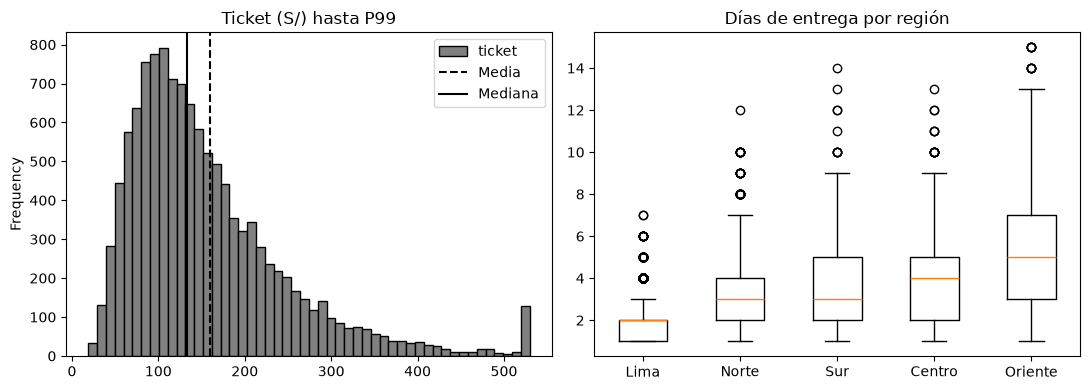

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["ticket"].clip(upper=df["ticket"].quantile(0.99)).plot.hist(
    bins=50, ax=ax[0], color="gray", edgecolor="black")
ax[0].axvline(df["ticket"].mean(), ls="--", color="black", label="Media")
ax[0].axvline(df["ticket"].median(), ls="-", color="black", label="Mediana")
ax[0].set_title("Ticket (S/) hasta P99"); ax[0].legend()
datos = [df.loc[df.region == r, "dias_entrega"] for r in orden]
ax[1].boxplot(datos)
ax[1].set_xticks(range(1, 6), orden)
ax[1].set_title("Días de entrega por región")
plt.tight_layout();plt.savefig("fig_paso_1_4.png", dpi=150);plt.show()

**1.** El histograma del ticket muestra una distribución con cola larga a la derecha, concentrada en valores bajos-medios con pocos valores muy altos que estiran la cola (asimetría positiva).

**2.** Sí, el boxplot confirma el mismo orden del paso 1.3: Lima tiene la caja más baja y compacta y Oriente la más alta y dispersa, siguiendo el orden Lima < Norte < Sur < Centro < Oriente.

## Parte 2. Detección y tratamiento de valores atípicos

### Paso 2.1. Comparar cuatro criterios de detección

In [8]:
t = df["ticket"]
q1, q3 = t.quantile([0.25, 0.75]); iqr = q3 - q1
df["out_iqr"] = (t < q1 - 1.5*iqr) | (t > q3 + 1.5*iqr)
df["out_z"] = ((t - t.mean()) / t.std()).abs() > 3
mad = stats.median_abs_deviation(t)
df["out_zrob"] = (0.6745 * (t - t.median()) / mad).abs() > 3.5
lt = np.log(t); lq1, lq3 = lt.quantile([0.25, 0.75]); liqr = lq3 - lq1
df["out_iqr_log"] = (lt < lq1 - 1.5*liqr) | (lt > lq3 + 1.5*liqr)
print(df[["out_iqr", "out_z", "out_zrob", "out_iqr_log"]].sum())

out_iqr        516
out_z          114
out_zrob       372
out_iqr_log    120
dtype: int64


**1.** El criterio z detecta menos atípicos (114) que el z robusto (372) porque la media y la desviación estándar que usa z ya están infladas por los propios valores extremos, así que el umbral de 3 desviaciones queda más ancho y "esconde" (enmascara) atípicos que sí detecta el z robusto, que se basa en la mediana y el MAD y no se deja arrastrar por esos valores.

**2.** El IQR sobre log(ticket) es más adecuado porque el ticket crudo es muy asimétrico; al tomar logaritmo la distribución se acerca a una forma simétrica y ahí el criterio IQR (pensado para distribuciones simétricas) deja de marcar como atípico a todo un lado de una cola que en realidad es normal para este tipo de variable (120 casos, contra los 516 que marca el IQR directo sobre el ticket).

### Paso 2.2. Impacto de los atípicos en las medidas

In [9]:
sin_out = df.loc[~df["out_iqr_log"], "ticket"]
comparacion = pd.DataFrame({
    "con_atipicos": [t.mean(), t.median(), t.std()],
    "sin_atipicos_log": [sin_out.mean(), sin_out.median(), sin_out.std()]},
    index=["media", "mediana", "desv_est"])
comparacion["cambio_%"] = (comparacion.iloc[:, 1]
                           / comparacion.iloc[:, 0] - 1) * 100
print(comparacion.round(2))

          con_atipicos  sin_atipicos_log  cambio_%
media         160.1100          154.4800   -3.5100
mediana       133.6800          133.4000   -0.2100
desv_est      126.3000           87.2900  -30.8900


**1.** La desviación estándar es la más sensible a los atípicos (cae 30.89% al quitarlos) y la mediana es la más estable (cambia apenas 0.21%); la media queda en un punto intermedio (-3.51%).

**2.** No eliminaría estos registros porque son compras corporativas reales, no errores de captura. Una alternativa es reportarlos aparte: usar la mediana o la media recortada para describir el "ticket típico" y mantener todos los datos para calcular la venta total.

## Parte 3. Forma de la distribución e intervalos de confianza

### Paso 3.1. Gráficos Q-Q y prueba de normalidad

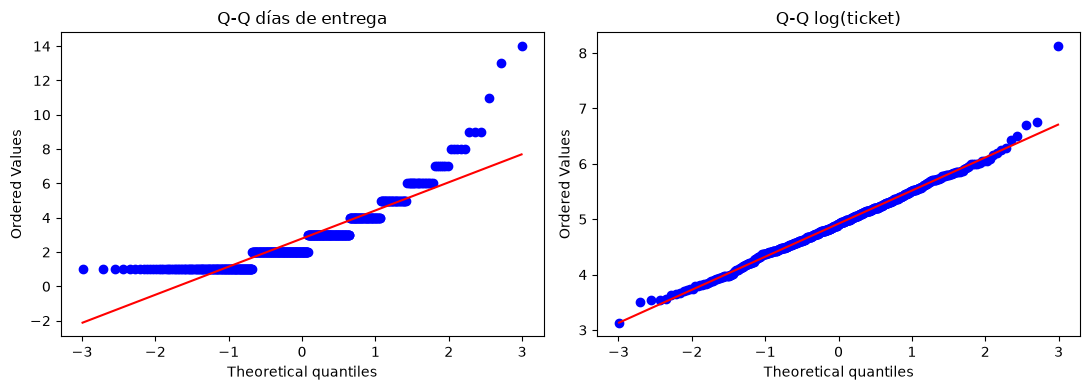

Shapiro días: ShapiroResult(statistic=np.float64(0.8246775471022242), pvalue=np.float64(5.583593255666212e-23))
Asimetría días: 1.6064585942312573


In [10]:
rng = np.random.default_rng(SEMILLA)
muestra = rng.choice(df["dias_entrega"].to_numpy(), 500, replace=False)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(muestra, dist="norm", plot=ax[0])
ax[0].set_title("Q-Q días de entrega")
stats.probplot(np.log(df["ticket"].sample(500, random_state=SEMILLA)),
               dist="norm", plot=ax[1]); ax[1].set_title("Q-Q log(ticket)")
plt.tight_layout(); plt.savefig("fig_paso_3_1.png", dpi=150); plt.show()
print("Shapiro días:", stats.shapiro(muestra))
print("Asimetría días:", stats.skew(df["dias_entrega"]))

**1.** Los "escalones" aparecen porque dias_entrega es discreta (valores enteros de 1 a 15): muchas observaciones comparten el mismo valor exacto, así que en el gráfico se agrupan en columnas verticales en vez de formar una línea continua de puntos.

**2.** Sí es razonable usar una prueba t aunque Shapiro rechace la normalidad (p=5.58e-23) y la asimetría sea 1.61, porque con n=12 000 el Teorema del Límite Central garantiza que la distribución muestral de la media es aproximadamente normal sin importar la forma de los datos individuales; el supuesto de normalidad de la prueba t aplica al estadístico (la media), no a los datos crudos.

### Paso 3.2. IC bootstrap del percentil 90 del ticket

In [11]:
def ic_bootstrap_p90(x):
    res = stats.bootstrap((x.to_numpy(),),
                          lambda v, axis: np.percentile(v, 90, axis=axis),
                          n_resamples=2000, method="percentile",
                          vectorized=True, random_state=SEMILLA)
    return np.percentile(x, 90), res.confidence_interval
for r in ["Lima", "Oriente"]:
    p90, ic = ic_bootstrap_p90(df.loc[df.region == r, "ticket"])
    print(f"{r:8s} P90 = {p90:8.2f}| IC95% = [{ic.low:.2f};{ic.high:.2f}]")

Lima     P90 =   292.44| IC95% = [286.81;300.06]
Oriente  P90 =   254.72| IC95% = [233.97;269.81]


**1.** No se superponen: el IC de Lima va de 286.81 a 300.06 y el de Oriente de 233.97 a 269.81, sin ningún punto en común. Se concluye que el P90 del ticket es más alto en Lima que en Oriente con 95% de confianza.

**2.** Usaría el límite superior del IC como umbral (Lima 300.06, Oriente 269.81), porque es el lado conservador para la empresa: fijar el umbral más alto reduce el riesgo de regalar envío gratis a pedidos que en realidad no llegan al P90 real.

### Paso 3.3. IC de la media y efecto del tamaño de muestra

In [12]:
x = df["dias_entrega"]
ic_t = stats.t.interval(0.95, len(x)-1, loc=x.mean(), scale=stats.sem(x))
print("Media días:", round(x.mean(), 3), "IC95%:", np.round(ic_t, 3))
for n in [100, 400, 1600]:
    s = x.sample(n, random_state=SEMILLA)
    ic = stats.t.interval(0.95, n-1, loc=s.mean(), scale=stats.sem(s))
    print(f"n={n:5d}  ancho IC = {ic[1]-ic[0]:.3f}")

Media días: 2.872 IC95%: [2.839 2.905]
n=  100  ancho IC = 0.820
n=  400  ancho IC = 0.380
n= 1600  ancho IC = 0.182


**1.** Cada vez que n se cuadruplica el ancho se reduce casi a la mitad (0.820→0.380 es una razón de 0.46, y 0.380→0.182 es una razón de 0.48), lo que coincide con la teoría: el ancho del IC es proporcional a 1/√n y √4=2.

**2.** El IC95% de la media es [2.839, 2.905]. La interpretación correcta es que si se repitiera el muestreo muchas veces y se construyera un intervalo así en cada una, el 95% de esos intervalos contendría a la verdadera media poblacional, no que hay 95% de probabilidad de que la media esté en este intervalo puntual.

## Parte 4. Comparación de grupos

### Paso 4.1. Días de entrega: Web vs. App

H0: la mediana (y media) de días de entrega es igual entre Web y App.

H1: la mediana (y media) de días de entrega difiere entre Web y App (bilateral, alfa = 0.05).

In [13]:
web = df.loc[df.canal == "Web", "dias_entrega"]
app = df.loc[df.canal == "App", "dias_entrega"]
print("Mediana Web/App:", web.median(), app.median())
print("Media   Web/App:", round(web.mean(), 3), round(app.mean(), 3))
print("Levene:", stats.levene(web, app))
print("Welch :", stats.ttest_ind(app, web, equal_var=False))
mw = stats.mannwhitneyu(app, web, alternative="two-sided")
r_rb = 1 - 2 * mw.statistic / (len(app) * len(web))
print("Mann-Whitney:", mw, "| r biserial de rangos:", round(r_rb, 4))

Mediana Web/App: 2.0 2.0
Media   Web/App: 2.846 2.905
Levene: LeveneResult(statistic=np.float64(2.7526769766277184), pvalue=np.float64(0.09711788403286985))
Welch : TtestResult(statistic=np.float64(1.7397758577422395), pvalue=np.float64(0.08192580424613954), df=np.float64(11219.852473218232))
Mann-Whitney: MannwhitneyuResult(statistic=np.float64(18012775.0), pvalue=np.float64(0.18983411011426599)) | r biserial de rangos: -0.0136


**1.** No se rechaza H0 (Welch p=0.082, Mann-Whitney p=0.190, ambos por encima de 0.05): con estos datos no hay evidencia de que los días de entrega difieran entre Web y App.

**2.** Que el resultado no sea significativo no demuestra que los canales sean iguales, solo que no hubo evidencia suficiente para rechazar la igualdad. A diferencia del ticket (que sí mostró diferencia significativa en la teoría), aquí el tamaño del efecto es casi nulo (r biserial = -0.0136), así que si existe una diferencia real probablemente es demasiado chica para detectarla incluso con miles de datos.

### Paso 4.2. Días de entrega entre regiones: Kruskal-Wallis

In [14]:
grupos = [df.loc[df.region == r, "dias_entrega"] for r in orden]
kw = stats.kruskal(*grupos)
n_total = sum(len(g) for g in grupos); k = len(grupos)
eps2 = (kw.statistic - k + 1) / (n_total - k)     # épsilon cuadrado
print("Kruskal-Wallis:", kw, "| epsilon^2 =", round(eps2, 4))
print("ANOVA (referencia):", stats.f_oneway(*grupos))

Kruskal-Wallis: KruskalResult(statistic=np.float64(3859.833062133577), pvalue=np.float64(0.0)) | epsilon^2 = 0.3215
ANOVA (referencia): F_onewayResult(statistic=np.float64(1362.8468425305773), pvalue=np.float64(0.0))


**1.** El épsilon cuadrado es 0.3215, es decir que la región explica cerca del 32% de la variabilidad de los días de entrega; según los umbrales usuales (pequeño ≈0.01, mediano ≈0.06, grande ≈0.14) es un efecto grande.

**2.** Se prefiere Kruskal-Wallis porque dias_entrega es discreta y muy asimétrica (asimetría 1.61 en el paso 3.1) y no cumple el supuesto de normalidad que pide el ANOVA; Kruskal-Wallis compara rangos en vez de medias, así que no depende de ese supuesto.

### Paso 4.3. Comparaciones post hoc con corrección múltiple

In [15]:
from itertools import combinations
pares, pvals, difs = [], [], []
for a, b in combinations(orden, 2):
    xa = df.loc[df.region == a, "dias_entrega"]
    xb = df.loc[df.region == b, "dias_entrega"]
    pares.append(f"{a} vs {b}")
    pvals.append(stats.mannwhitneyu(xa, xb).pvalue)
    difs.append(xa.median() - xb.median())
posthoc = pd.DataFrame({"par": pares, "dif_mediana": difs, "p_crudo": pvals})
posthoc["p_bonf"] = multipletests(pvals, method="bonferroni")[1]
posthoc["p_holm"] = multipletests(pvals, method="holm")[1]
posthoc["p_bh"] = multipletests(pvals, method="fdr_bh")[1]
posthoc["signif_holm"] = posthoc["p_holm"] < 0.05
print(posthoc.round(4).to_string(index=False))

              par  dif_mediana  p_crudo  p_bonf  p_holm   p_bh  signif_holm
    Lima vs Norte      -1.0000   0.0000  0.0000  0.0000 0.0000         True
      Lima vs Sur      -1.0000   0.0000  0.0000  0.0000 0.0000         True
   Lima vs Centro      -2.0000   0.0000  0.0000  0.0000 0.0000         True
  Lima vs Oriente      -3.0000   0.0000  0.0000  0.0000 0.0000         True
     Norte vs Sur       0.0000   0.0000  0.0000  0.0000 0.0000         True
  Norte vs Centro      -1.0000   0.0000  0.0000  0.0000 0.0000         True
 Norte vs Oriente      -2.0000   0.0000  0.0000  0.0000 0.0000         True
    Sur vs Centro      -1.0000   0.0000  0.0000  0.0000 0.0000         True
   Sur vs Oriente      -2.0000   0.0000  0.0000  0.0000 0.0000         True
Centro vs Oriente      -1.0000   0.0000  0.0000  0.0000 0.0000         True


**1.** Con 10 pruebas sin corregir, la probabilidad de al menos un falso positivo es 1-(1-0.05)^10 ≈ 0.40, un 40%, muy por encima del 5% nominal.

**2.** Es posible porque Mann-Whitney no compara solo medianas: compara si los rangos de un grupo tienden a ser sistemáticamente más altos o más bajos que los del otro en toda la distribución. Norte y Sur pueden compartir la mediana pero tener formas o dispersiones distintas, y eso alcanza para que la prueba marque diferencia aunque la "diferencia de medianas" de la tabla sea 0.

## Parte 5. Asociación entre variables

### Paso 5.1. Canal x método de pago: chi-cuadrado

In [16]:
tabla = pd.crosstab(df["canal"], df["metodo_pago"])
print(tabla)
pct = pd.crosstab(df["canal"], df["metodo_pago"], normalize="index") * 100
print(pct.round(1))
chi = stats.chi2_contingency(tabla)
v = stats.contingency.association(tabla, method="cramer")
print(f"chi2 = {chi.statistic:.3f} | gl = {chi.dof} | "
      f"p = {chi.pvalue:.4f} | V = {v:.4f}")
print("Esperadas >= 5:",(chi.expected_freq >= 5).all())

metodo_pago  Billetera digital  Contra entrega  Tarjeta
canal                                                  
App                       2181            1046     2097
Web                       2803            1276     2597
metodo_pago  Billetera digital  Contra entrega  Tarjeta
canal                                                  
App                    41.0000         19.6000  39.4000
Web                    42.0000         19.1000  38.9000
chi2 = 1.359 | gl = 2 | p = 0.5070 | V = 0.0106
Esperadas >= 5: True


**1.** No existe asociación relevante entre canal y método de pago: el p-valor (0.507) no es significativo y V=0.0106 es prácticamente cero.

**2.** Comparado con la V=0.18 de región x método de pago en la teoría, región es mucho más útil para segmentar la estrategia de pagos: canal casi no distingue preferencia de pago (V=0.01), mientras que región sí captura una asociación de magnitud moderada.

### Paso 5.2. Demora vs. satisfacción por región (Spearman)

In [17]:
d = df.dropna(subset=["satisfaccion"])
for nombre, g in d.groupby("region"):
    rho = stats.spearmanr(g["dias_entrega"], g["satisfaccion"])
    print(f"{nombre:8s} n={len(g):5d} rho={rho.statistic:6.3f} "
          f"p={rho.pvalue:.2e}")
print("Global:", stats.spearmanr(d["dias_entrega"], d["satisfaccion"]))

Centro   n= 1282 rho=-0.408 p=1.66e-52
Lima     n= 5279 rho=-0.215 p=5.07e-56
Norte    n= 2343 rho=-0.349 p=3.96e-68
Oriente  n=  889 rho=-0.562 p=3.38e-75
Sur      n= 2027 rho=-0.386 p=8.12e-73
Global: SignificanceResult(statistic=np.float64(-0.3766124437111657), pvalue=np.float64(0.0))


**1.** Sí, la asociación negativa se mantiene en las cinco regiones; es más fuerte en Oriente (rho=-0.562) y más débil en Lima (rho=-0.215).

**2.** Es importante revisar por segmentos porque una correlación global puede ocultar diferencias entre grupos (paradoja de Simpson). Acá la global (-0.377) cae dentro del rango de las regionales, pero la fuerza real cambia bastante según la región (de -0.215 a -0.562), algo que no se ve si solo se mira el dato agregado.

## Parte 6. Experimento A/B desde datos crudos

### Paso 6.1. Cargar datos y verificar SRM

In [18]:
ab = pd.read_csv("experimento_checkout_2026.csv", parse_dates=["fecha"])
print(ab.shape); print(ab.head())
conteo = ab["variante"].value_counts().sort_index()
print(conteo)
srm = stats.chisquare(conteo, f_exp=[len(ab)/2, len(ab)/2])
print("Prueba SRM:", srm)

(40250, 7)
  usuario_id      fecha variante dispositivo  gasto_previo_30d  convirtio  monto_compra
0    U100000 2026-08-11        A     Android           46.0600          0           NaN
1    U100001 2026-08-05        A     Desktop           74.7100          1       90.1200
2    U100002 2026-08-09        A     Desktop           73.4100          0           NaN
3    U100003 2026-08-13        B     Android           61.2300          0           NaN
4    U100004 2026-08-17        B     Android           82.1500          0           NaN
variante
A    20078
B    20172
Name: count, dtype: int64
Prueba SRM: Power_divergenceResult(statistic=np.float64(0.219527950310559), pvalue=np.float64(0.6393998321416612))


**1.** No hay evidencia de SRM: el p-valor (0.639) es muy superior a cualquier umbral usual y las proporciones observadas (20 078 vs 20 172) están cerca del 50/50 esperado. Si el p-valor fuera menor que 0.001 pausaría el análisis de resultados hasta encontrar y corregir la causa del desbalance, por ejemplo un bug en la asignación aleatoria o un filtro que excluye usuarios distinto en cada variante.

### Paso 6.2. Prueba de dos proporciones

In [19]:
res = ab.groupby("variante")["convirtio"].agg(conversiones="sum", usuarios="count")
res["tasa_%"] = res.conversiones / res.usuarios * 100
print(res)
z, p = proportions_ztest(res.conversiones[["B", "A"]], res.usuarios[["B", "A"]])
nA, nB = res.loc["A", "usuarios"], res.loc["B", "usuarios"]
pA = res.loc["A", "conversiones"] / nA
pB = res.loc["B", "conversiones"] / nB
se = np.sqrt(pA*(1-pA)/nA + pB*(1-pB)/nB)
dif = pB - pA
print(f"z = {z:.3f} | p = {p:.5f}")
print(f"Diferencia = {100*dif:.2f} pp | IC95% = "
      f"[{100*(dif-1.96*se):.2f} ; {100*(dif+1.96*se):.2f}] pp")
print(f"Lift relativo = {100*(pB/pA-1):.2f}%")
for v_ in ["A", "B"]:
    ic = proportion_confint(res.loc[v_, "conversiones"],
                            res.loc[v_, "usuarios"], method="wilson")
    print(v_, "IC Wilson:", np.round(ic, 4))

          conversiones  usuarios  tasa_%
variante                                
A                 1917     20078  9.5478
B                 2101     20172 10.4154
z = 2.903 | p = 0.00369
Diferencia = 0.87 pp | IC95% = [0.28 ; 1.45] pp
Lift relativo = 9.09%
A IC Wilson: [0.0915 0.0996]
B IC Wilson: [0.1    0.1084]


**1.** El checkout B convierte 0.87 puntos porcentuales más que A (10.42% vs 9.55%), con IC95% de [0.28; 1.45] pp y p=0.0037, así que se rechaza H0: hay una mejora real y significativa en la conversión.

**2.** Con 300 000 usuarios al mes, el límite inferior del IC (0.28 pp) da 840 conversiones adicionales y S/ 21 000 de margen extra; el límite superior (1.45 pp) da 4 350 conversiones y S/ 108 750. Con el punto central (0.87 pp) el impacto esperado es de unas 2 610 conversiones y S/ 65 250 al mes.

### Paso 6.3. Métrica secundaria: monto de compra

In [20]:
compras = ab.dropna(subset=["monto_compra"])
mA = compras.loc[compras.variante == "A", "monto_compra"]
mB = compras.loc[compras.variante == "B", "monto_compra"]
print("Mediana A/B:", round(mA.median(), 2), round(mB.median(), 2))
print("Welch:", stats.ttest_ind(mB, mA, equal_var=False))
print("Mann-Whitney:", stats.mannwhitneyu(mB, mA))

Mediana A/B: 134.47 136.32
Welch: TtestResult(statistic=np.float64(0.11514697026696559), pvalue=np.float64(0.9083344427700777), df=np.float64(3977.593152890964))
Mann-Whitney: MannwhitneyuResult(statistic=np.float64(2032438.5), pvalue=np.float64(0.6119903241014631))


**1.** No, el nuevo checkout no modifica el monto de compra de forma significativa (Welch p=0.908, Mann-Whitney p=0.612); las medianas son casi iguales (134.47 vs 136.32). Es favorable para el negocio: se gana conversión adicional sin sacrificar el valor promedio de cada compra.

### Paso 6.4. Análisis por dispositivo con corrección de Holm

In [21]:
filas = []
for dsp, g in ab.groupby("dispositivo"):
    c = g.groupby("variante")["convirtio"].agg(["sum", "count"])
    z_, p_ = proportions_ztest(c["sum"][["B", "A"]], c["count"][["B", "A"]])
    tasa = 100 * c["sum"] / c["count"]
    filas.append({"dispositivo": dsp, "tasa_A_%": tasa["A"],
                  "tasa_B_%": tasa["B"], "p_crudo": p_})
seg = pd.DataFrame(filas)
seg["p_holm"] = multipletests(seg["p_crudo"], method="holm")[1]
print(seg.round(4).to_string(index=False))

dispositivo  tasa_A_%  tasa_B_%  p_crudo  p_holm
    Android    8.2237    9.1303   0.0199  0.0399
    Desktop   11.4390   10.9262   0.3708  0.3708
        iOS   10.2477   13.1806   0.0001  0.0003


**1.** El efecto se mantiene significativo tras Holm en Android (p_holm=0.0399) y en iOS (p_holm=0.0003); en Desktop no (p_holm=0.371).

**2.** No desplegaría B solo en Android e iOS a partir de este análisis, porque es un análisis de segmentos no planificado de antemano: mirar varios subgrupos después de ver los resultados aumenta el riesgo de encontrar diferencias "significativas" por azar, el mismo problema de comparaciones múltiples del paso 4.3. Conviene tratar esto como hipótesis a confirmar en un experimento nuevo diseñado específicamente para comparar por dispositivo.

### Paso 6.5. Potencia y simulación del peeking

In [22]:
es = proportion_effectsize(0.0955 * 1.05, 0.0955)
n_req = NormalIndPower().solve_power(es, alpha=0.05, power=0.80)
print("Usuarios por grupo para lift 5%:", int(np.ceil(n_req)))
rng = np.random.default_rng(SEMILLA)
n_sim, n_max, cada, tasa = 1000, 20000, 1000, 0.0955   # H0 verdadera
falsos_fijo = falsos_peek = 0
for _ in range(n_sim):
    a = rng.random(n_max) < tasa
    b = rng.random(n_max) < tasa
    detenido = False
    for n in range(cada, n_max + 1, cada):
        _, p_ = proportions_ztest([b[:n].sum(), a[:n].sum()], [n, n])
        if p_ < 0.05:
            detenido = True
            break
    falsos_peek += detenido
    _, p_final = proportions_ztest([b.sum(), a.sum()], [n_max, n_max])
    falsos_fijo += p_final < 0.05
print(f"Error tipo I con n fijo : {falsos_fijo/n_sim:.3f}")
print(f"Error tipo I con peeking: {falsos_peek/n_sim:.3f}")

Usuarios por grupo para lift 5%: 60788


Error tipo I con n fijo : 0.053
Error tipo I con peeking: 0.251


**1.** El error tipo I real sube de 0.053 (cercano al 0.05 nominal) a 0.251 al revisar el resultado 20 veces durante el experimento, casi 5 veces más de lo esperado.

**2.** Se necesitarían 60 788 usuarios por grupo para detectar un lift del 5% con 80% de potencia, mucho más que los cerca de 20 000 usuarios por variante que tuvo el experimento actual (que en realidad detectó un lift mayor, de 9.09%).

## Parte 7. Actividad propuesta individual

### Paso 7.1. Filtrar la operación asignada

In [23]:
CODIGO = "22200255"          # código de matrícula
ops = ["Transferencia", "Pago QR", "Recarga celular",
       "Pago de servicios", "Consulta de saldo"]
mi_operacion = ops[int(CODIGO[-1]) % 5]
api = pd.read_csv("transacciones_api_billetera_2026.csv")
mi = api[api["tipo_operacion"] == mi_operacion].copy()
print("Operación asignada:", mi_operacion, "| registros:", len(mi))

Operación asignada: Transferencia | registros: 4542


### Tarea A1. Calidad y descriptiva

In [24]:
print(mi.isna().sum())
print((mi.isna().sum() / len(mi) * 100).round(2))
tabla_v1 = mi.groupby("version_api")["latencia_ms"].apply(resumen_robusto).unstack()
cols_a1 = ["n", "media", "mediana", "IQR", "CV_%", "asimetria", "P90", "P95"]
print(tabla_v1[cols_a1].round(2))

transaccion_id     0
tipo_operacion     0
version_api        0
datacenter         0
hora               0
franja             0
latencia_ms       19
error              0
satisfaccion      58
dtype: int64
transaccion_id   0.0000
tipo_operacion   0.0000
version_api      0.0000
datacenter       0.0000
hora             0.0000
franja           0.0000
latencia_ms      0.4200
error            0.0000
satisfaccion     1.2800
dtype: float64
                    n    media  mediana      IQR    CV_%  asimetria      P90      P95
version_api                                                                          
v1          2265.0000 345.9700 299.9000 197.5000 86.4600    17.5900 545.9400 649.3000
v2          2258.0000 304.0100 261.5500 171.2700 74.1300     8.9200 488.4600 588.0000


Los faltantes de latencia_ms (19, 0.42%) y satisfaccion (58, 1.28%) se dejan como NaN y se excluyen fila por fila en cada cálculo (dropna dentro de resumen_robusto y en las pruebas de asociación), en vez de imputarlos, porque no hay una razón de negocio para inventar un valor de latencia o de satisfacción que no se midió.

En la tabla, v1 ya se ve más lento que v2 en todas las medidas: mediana 299.90 ms vs 261.55 ms, P90 545.94 ms vs 488.46 ms y P95 649.30 ms vs 588.00 ms, con v1 además más asimétrico (asimetría 17.59 vs 8.92).

### Tarea A2. Atípicos

In [25]:
lat = mi["latencia_ms"].dropna()
llat = np.log(lat)
lq1, lq3 = llat.quantile([0.25, 0.75]); liqr = lq3 - lq1
out_log = (llat < lq1 - 1.5*liqr) | (llat > lq3 + 1.5*liqr)
mi_out = pd.Series(out_log, name="out_log").reindex(mi.index, fill_value=False)
mi["out_log"] = mi_out
print(mi.groupby("version_api")["out_log"].sum())
print(mi.groupby("version_api")["out_log"].mean().mul(100).round(2))

version_api
v1    24
v2    22
Name: out_log, dtype: int64
version_api
v1   1.0600
v2   0.9700
Name: out_log, dtype: float64


Los atípicos se conservan para el análisis principal en vez de eliminarse, porque en latencia de una API los valores altos son justamente los que le interesan a SRE (colas de latencia, picos de saturación); se documentan aparte y se usan estadísticos robustos (mediana, P95, pruebas no paramétricas) que no dependen de excluirlos.

### Tarea A3. Latencia v1 vs. v2

H0: la distribución de latencia_ms es igual entre v1 y v2.

H1: la distribución de latencia_ms difiere entre v1 y v2 (bilateral, alfa = 0.05).

In [26]:
v1 = mi.loc[mi.version_api == "v1", "latencia_ms"].dropna()
v2 = mi.loc[mi.version_api == "v2", "latencia_ms"].dropna()
print("Mediana v1/v2:", v1.median(), v2.median())
print("Media   v1/v2:", round(v1.mean(), 3), round(v2.mean(), 3))
print("Levene:", stats.levene(v1, v2))
print("Welch :", stats.ttest_ind(v2, v1, equal_var=False))
mw = stats.mannwhitneyu(v2, v1, alternative="two-sided")
r_rb = 1 - 2 * mw.statistic / (len(v2) * len(v1))
print("Mann-Whitney:", mw, "| r biserial de rangos:", round(r_rb, 4))
dif_mediana = v2.median() - v1.median()
dif_pct = (v2.median() / v1.median() - 1) * 100
print(f"Diferencia de mediana v2-v1 = {dif_mediana:.2f} ms ({dif_pct:.2f}%)")

Mediana v1/v2: 299.9 261.55
Media   v1/v2: 345.974 304.006
Levene: LeveneResult(statistic=np.float64(5.492163937933613), pvalue=np.float64(0.01914498429902865))
Welch : TtestResult(statistic=np.float64(-5.330097222443311), pvalue=np.float64(1.0330211090858396e-07), df=np.float64(4207.854969469381))
Mann-Whitney: MannwhitneyuResult(statistic=np.float64(2174254.5), pvalue=np.float64(2.764214332829618e-18)) | r biserial de rangos: 0.1497
Diferencia de mediana v2-v1 = -38.35 ms (-12.79%)


In [27]:
def ic_bootstrap_p95(x):
    res = stats.bootstrap((x.to_numpy(),),
                          lambda v, axis: np.percentile(v, 95, axis=axis),
                          n_resamples=2000, method="percentile",
                          vectorized=True, random_state=SEMILLA)
    return np.percentile(x, 95), res.confidence_interval
for vname, serie in [("v1", v1), ("v2", v2)]:
    p95, ic = ic_bootstrap_p95(serie)
    print(f"{vname:4s} P95 = {p95:8.2f} | IC95% = [{ic.low:.2f};{ic.high:.2f}]")

v1   P95 =   649.30 | IC95% = [621.20;695.06]


v2   P95 =   588.00 | IC95% = [562.20;617.76]


Como Levene rechaza la igualdad de varianzas (p=0.019) y la latencia tiene cola larga, me apoyo en Mann-Whitney como prueba principal: la diferencia es muy significativa (p=2.76e-18) con un tamaño de efecto pequeño-moderado (r biserial de rangos = 0.15). En mediana, v2 es 38.35 ms más rápida que v1 (261.55 ms vs 299.90 ms, -12.79%). El P95 (la cola que le importa a SRE) también baja de 649.30 ms en v1 a 588.00 ms en v2, y los IC bootstrap al 95% no se superponen ([621.20;695.06] vs [562.20;617.76]), así que la mejora de v2 en la cola alta de latencia es consistente y no parece ruido de muestreo.

### Tarea A4. Errores v1 vs. v2

In [28]:
res_err = mi.groupby("version_api")["error"].agg(errores="sum", transacciones="count")
res_err["tasa_%"] = res_err.errores / res_err.transacciones * 100
print(res_err)
z_e, p_e = proportions_ztest(res_err.errores[["v2", "v1"]], res_err.transacciones[["v2", "v1"]])
n1, n2 = res_err.loc["v1", "transacciones"], res_err.loc["v2", "transacciones"]
p1 = res_err.loc["v1", "errores"] / n1
p2 = res_err.loc["v2", "errores"] / n2
se_e = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
dif_e = p2 - p1
print(f"z = {z_e:.3f} | p = {p_e:.5f}")
print(f"Diferencia = {100*dif_e:.3f} pp | IC95% = "
      f"[{100*(dif_e-1.96*se_e):.3f} ; {100*(dif_e+1.96*se_e):.3f}] pp")
if p1 > 0:
    print(f"Lift relativo = {100*(p2/p1-1):.2f}%")
es_e = proportion_effectsize(p2, p1)
n_req_e = NormalIndPower().solve_power(abs(es_e), alpha=0.05, power=0.80)
print("n por grupo necesario para la diferencia observada:", int(np.ceil(n_req_e)))
print("n por grupo disponible:", int(min(n1, n2)))

             errores  transacciones  tasa_%
version_api                                
v1                47           2273  2.0678
v2                31           2269  1.3662
z = -1.820 | p = 0.06883
Diferencia = -0.702 pp | IC95% = [-1.457 ; 0.054] pp
Lift relativo = -33.93%
n por grupo necesario para la diferencia observada: 5327
n por grupo disponible: 2269


La tasa de error baja de 2.07% en v1 a 1.37% en v2 (-33.93% relativo), pero la diferencia no es significativa (p=0.069) y el IC de la diferencia [-1.457; 0.054] pp cruza el cero. Esto puede deberse a falta de potencia: para detectar con 80% de potencia una diferencia de este tamaño harían falta unos 5 327 usuarios por grupo, y la muestra disponible por versión es de solo 2 269, menos de la mitad. No se puede concluir que v2 tenga menos errores que v1 con la evidencia actual, aunque la dirección del efecto favorece a v2.

### Tarea A5. Datacenter y franja

In [29]:
dcs = sorted(mi["datacenter"].dropna().unique())
grupos_dc = [mi.loc[mi.datacenter == d, "latencia_ms"].dropna() for d in dcs]
kw_dc = stats.kruskal(*grupos_dc)
n_total_dc = sum(len(g) for g in grupos_dc); k_dc = len(grupos_dc)
eps2_dc = (kw_dc.statistic - k_dc + 1) / (n_total_dc - k_dc)
print("Datacenters:", dcs)
print("Kruskal-Wallis:", kw_dc, "| epsilon^2 =", round(eps2_dc, 4))
print(mi.groupby("datacenter")["latencia_ms"].median())

Datacenters: ['Arequipa', 'Lima', 'Trujillo']
Kruskal-Wallis: KruskalResult(statistic=np.float64(38.45673472522396), pvalue=np.float64(4.458883838717745e-09)) | epsilon^2 = 0.0081
datacenter
Arequipa   298.5500
Lima       266.8000
Trujillo   292.2000
Name: latencia_ms, dtype: float64


In [30]:
from itertools import combinations as comb
pares_dc, pvals_dc, difs_dc = [], [], []
for a, b in comb(dcs, 2):
    xa = mi.loc[mi.datacenter == a, "latencia_ms"].dropna()
    xb = mi.loc[mi.datacenter == b, "latencia_ms"].dropna()
    pares_dc.append(f"{a} vs {b}")
    pvals_dc.append(stats.mannwhitneyu(xa, xb).pvalue)
    difs_dc.append(xa.median() - xb.median())
posthoc_dc = pd.DataFrame({"par": pares_dc, "dif_mediana": difs_dc, "p_crudo": pvals_dc})
posthoc_dc["p_holm"] = multipletests(pvals_dc, method="holm")[1]
posthoc_dc["signif_holm"] = posthoc_dc["p_holm"] < 0.05
print(posthoc_dc.round(4).to_string(index=False))

                 par  dif_mediana  p_crudo  p_holm  signif_holm
    Arequipa vs Lima      31.7500   0.0000  0.0000         True
Arequipa vs Trujillo       6.3500   0.1699  0.1699        False
    Lima vs Trujillo     -25.4000   0.0000  0.0000         True


In [31]:
d_sat = mi.dropna(subset=["satisfaccion", "latencia_ms"])
rho_sat = stats.spearmanr(d_sat["latencia_ms"], d_sat["satisfaccion"])
print("Spearman latencia vs satisfaccion:", rho_sat)

Spearman latencia vs satisfaccion: SignificanceResult(statistic=np.float64(-0.40371553132742866), pvalue=np.float64(1.022467113449513e-174))


Hay diferencia significativa de latencia entre datacenters (Kruskal-Wallis p=4.46e-09), pero el efecto es chico: epsilon^2=0.0081, es decir que el datacenter explica menos del 1% de la variabilidad de la latencia. Con la corrección de Holm, Lima resulta distinto de Arequipa (31.75 ms más rápido) y de Trujillo (25.40 ms más rápido), mientras que Arequipa vs Trujillo no es significativo (p_holm=0.17). La correlación de Spearman entre latencia y satisfacción es de -0.40 (p≈0), una asociación negativa moderada: a mayor latencia, menor satisfacción reportada.

### Tarea A6. Recomendación ejecutiva

Para la operación Transferencia recomiendo completar la migración a v2. La latencia mediana baja de 299.90 ms a 261.55 ms (-12.79%), y el P95 baja de 649.30 ms [IC95% 621.20;695.06] a 588.00 ms [IC95% 562.20;617.76], sin superposición entre los intervalos, así que la mejora es consistente y no es ruido de muestreo (Mann-Whitney p=2.76e-18, efecto r=0.15). En errores, v2 muestra una tasa menor (1.37% vs 2.07%, -33.93% relativo) pero la diferencia no es significativa (IC95% de la diferencia [-1.457;0.054] pp, p=0.069): con solo 2 269 transacciones por versión no hay potencia suficiente (harían falta unas 5 327) para confirmar esa reducción, así que tampoco se puede garantizar que v2 no empeore ligeramente los errores. Dado que la latencia mejora de forma clara y consistente y no hay evidencia de que los errores empeoren, mi recomendación es seguir con la migración a v2 para esta operación, monitoreando la tasa de error con más volumen de tráfico antes de darla por cerrada del todo.